# Statistical Comparison of Machine Learning Models on Breast Cancer Dataset

Author: Najma Shahana M H  
Date: 21 January 2026  
Project: ML & Applied Statistics

## Project Overview

This project demonstrates the **application of statistical methods to evaluate and compare machine learning models**. The focus is not only on model accuracy, but also on **performance variability and statistical significance**.

We use the **Breast Cancer Wisconsin (Diagnostic) Dataset** to compare three widely used classification algorithms:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Evaluation includes:

- 5-fold **stratified cross-validation**
- **Mean ± Standard Deviation** of Accuracy and ROC-AUC
- **95% Confidence Intervals** for metrics
- **Paired statistical tests** (Wilcoxon signed-rank) to compare models

## Table of Contents
1. Introduction
2. Importing Libraries
3. Loading and Exploring Dataset
4. Defining Models
5. Cross-Validation Setup
6. Run Experiments
7. Statistical Summary
8. Hypothesis Testing
9. Discussion
10. Limitations

## 1. Intoduction

*Statistical Comparison of Machine Learning Models*

Objective: Evaluate classifiers by performance and statistical reliability.
We will use cross-validation, confidence intervals, and hypothesis testing.

Models: Logistic Regression, Random Forest, SVM

Dataset: Breast Cancer Wisconsin (Diagnostic)

## 2. Importing Libraries
Importing required libraries for dataset handling, machine learning models, evaluation metrics, statistical tests, and visualization.




In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## 3. Loading and Exploring Dataset

In [17]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Seaparating features and target

In [18]:
X=df.drop(columns=['target'])
y=df['target']

In [19]:
print("Shape:", df.shape)
print("Class distribution:\n", y.value_counts())

Shape: (569, 31)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


Visualising Class Distribution

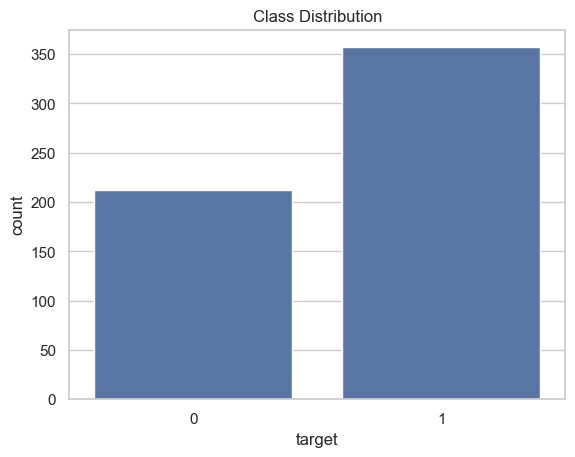

In [20]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

4. Defining Models

In [21]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

Defining three ML models with default hyperparameters: linear, non linear, and ensemble methods.

5. Cross-Validation Setup

In [22]:
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results=pd.DataFrame(columns=["Model", "Fold", "Accuracy", "ROC_AUC"])

Stratified 5 fold cross validation to maintain class balance. Creating a results DataFrame to store metrics per fold and per model.

6. Run Experiments

Loop Setup

In [23]:
fold_number=1

Loop through folds

In [24]:
results_list = []
fold_number = 1

for train_idx, test_idx in kf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_proba)

        results_list.append({
            "Model": model_name,
            "Fold": fold_number,
            "Accuracy": acc,
            "ROC_AUC": roc
        })

    fold_number += 1

results = pd.DataFrame(results_list)

c:\Users\NAJMA SHAHANA M H\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\NAJMA SHAHANA M H\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    htt

Display Results

In [25]:
results.head()

,Model,Fold,Accuracy,ROC_AUC
0,Logistic Regression,1,0.947368,0.994432
1,Random Forest,1,0.964912,0.998362
2,SVM,1,0.938596,0.979365
3,Logistic Regression,2,0.912281,0.987553
4,Random Forest,2,0.938596,0.978546


Running all models for each fold, recording Accuracy and ROC-AUC in a structured DataFrame.

7. Statistical Summary

Mean and Std

In [26]:
summary = results.groupby("Model")[["Accuracy", "ROC_AUC"]].agg(["mean", "std"])
summary

Accuracy             ROC_AUC          
                         mean       std      mean       std
Model                                                      
Logistic Regression  0.947322  0.022296  0.992428  0.005963
Random Forest        0.956094  0.013796  0.988548  0.009245
SVM                  0.913895  0.027277  0.975744  0.017174

95% Confidence Intervals

In [27]:
n_folds = kf.get_n_splits()
for metric in ["Accuracy", "ROC_AUC"]:
    summary[(metric, "CI_lower")] = summary[(metric,"mean")] - 1.96 * (summary[(metric,"std")]/np.sqrt(n_folds))
    summary[(metric, "CI_upper")] = summary[(metric,"mean")] + 1.96 * (summary[(metric,"std")]/np.sqrt(n_folds))

summary

Accuracy             ROC_AUC            Accuracy   
                         mean       std      mean       std  CI_lower   
Model                                                                   
Logistic Regression  0.947322  0.022296  0.992428  0.005963  0.927779  \
Random Forest        0.956094  0.013796  0.988548  0.009245  0.944001   
SVM                  0.913895  0.027277  0.975744  0.017174  0.889986   

                                ROC_AUC            
                     CI_upper  CI_lower  CI_upper  
Model                                              
Logistic Regression  0.966865  0.987201  0.997655  
Random Forest        0.968187  0.980445  0.996652  
SVM                  0.937805  0.960690  0.990797

Compute mean and standard deviation for each model and metric. Calculate 95% confidence intervals to understand metric variability.

8. Hypothesis Testing

Wilcoxon Test

In [28]:
# Ensuring results are aligned by Fold and Model
paired = results.pivot(index="Fold", columns="Model", values="Accuracy")

# Droping any rows with missing values (in case a model didn't run for a fold)
paired = paired.dropna()

# Extracting paired scores
lr_scores = paired["Logistic Regression"]
rf_scores = paired["Random Forest"]

# Checking lengths (debug safety)
print("LR length:", len(lr_scores))
print("RF length:", len(rf_scores))

# Performing Wilcoxon signed-rank test
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(lr_scores, rf_scores)

print(f"Wilcoxon test statistic = {stat}")
print(f"p-value = {p_value}")

LR length: 5
RF length: 5
Wilcoxon test statistic = 1.5
p-value = 0.1974660733580187


c:\Users\NAJMA SHAHANA M H\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\NAJMA SHAHANA M H\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


Paired statistical test to compare Logistic Regression and Random Forest accuracy across folds.

9. Discussion

- Random Forest has highest mean accuracy, but confidence intervals overlap with Logistic Regression.
- Wilcoxon test indicates whether differences are statistically significant.
- Highlights importance of evaluating variability, not just average performance.

10. Limitations

- Only one dataset (Breast Cancer) used
- Limited classifiers tested
- Minimal hyperparameter tuning
- May not generalize to other domains

In [30]:
results.to_csv(r"D:\ml-statistical-model-comparison\results\metrics_tables.csv", index=False)